In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!ls "/content/drive/MyDrive/facedectection.v2i.coco2"

README.roboflow.txt  test  train  valid


In [5]:
# Example
dataset_path = "/content/drive/MyDrive/facedectection.v2i.coco2"


In [6]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout


In [7]:
img_size = 224
batch_size = 32
epochs = 100  # or however many you want

train_dir = dataset_path  # adjust this


In [8]:
datagen = ImageDataGenerator(validation_split=0.2,
                             rescale=1./255,
                             horizontal_flip=True)

train_gen = datagen.flow_from_directory(train_dir,
                                        target_size=(img_size, img_size),
                                        batch_size=batch_size,
                                        class_mode='categorical',
                                        subset='training')

val_gen = datagen.flow_from_directory(train_dir,
                                      target_size=(img_size, img_size),
                                      batch_size=batch_size,
                                      class_mode='categorical',
                                      subset='validation')


Found 1197 images belonging to 3 classes.
Found 297 images belonging to 3 classes.


In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
for layer in base_model.layers:
    layer.trainable = False  # Freeze base layers

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=epochs)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 220s 5s/step - accuracy: 0.7627 - loss: 2.1018 - val_accuracy: 0.8754 - val_loss: 0.4387
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.8508 - loss: 0.4497 - val_accuracy: 0.6869 - val_loss: 0.7415
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 0.8612 - loss: 0.3541 - val_accuracy: 0.7778 - val_loss: 0.5106
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 263ms/step - accuracy: 0.8763 - loss: 0.3057 - val_accuracy: 0.8148 - val_loss: 0.4614
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.8880 - loss: 0.2893 - val_accuracy: 0.7912 - val_loss: 0.4990
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - accuracy: 0.8901 - loss: 0.3013 - val_accuracy: 0.8081 - val_loss: 0.4719
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - accuracy: 0.8891 - loss: 0.3156 - val_accuracy: 0.7407 - val_loss: 0.6324
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.8956 - loss: 0.2870 - va

In [11]:
model.save('/content/drive/MyDrive/vggface_custom_model.h5')


📤 Upload 2 face images to compare:


Saving img1.jpg to img1.jpg
Saving img6.jpg to img6.jpg


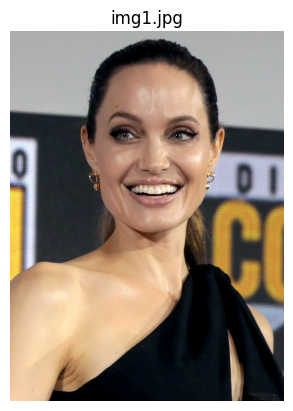

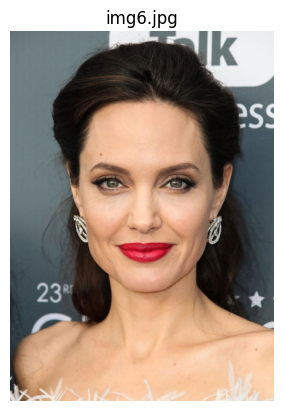


🔍 Cosine Similarity: 0.7190
✅ Likely the SAME person.


In [5]:
!pip install facenet-pytorch

from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
from google.colab import files
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(image_size=160, margin=0, min_face_size=40, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print("📤 Upload 2 face images to compare:")
uploaded = files.upload()
uploaded_files = list(uploaded.keys())

if len(uploaded_files) != 2:
    print("❗ Please upload exactly 2 images.")
else:
    embeddings = []
    for file in uploaded_files:
        img = Image.open(file).convert('RGB')
        face = mtcnn(img)
        if face is None:
            print(f"❌ No face detected in {file}.")
            continue
        face_embedding = model(face.unsqueeze(0).to(device)).detach().cpu().numpy()
        embeddings.append(face_embedding)

        plt.imshow(img)
        plt.title(f"{file}")
        plt.axis('off')
        plt.show()

    if len(embeddings) == 2:
        sim = cosine_similarity(embeddings[0], embeddings[1])[0][0]
        print(f"\n🔍 Cosine Similarity: {sim:.4f}")
        if sim > 0.7:
            print("✅ Likely the SAME person.")
        else:
            print("❌ Likely DIFFERENT people.")
